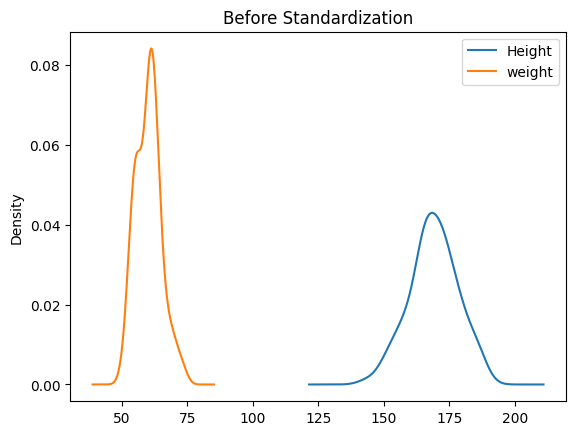

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 単位の違う2つのデータを作成
# 例: 身長（平均170cm, 分散10）と 体重（平均60kg, 分散5）
np.random.seed(42)
heights = np.random.normal(170, 10, 100)
weights = np.random.normal(60, 5, 100)

df = pd.DataFrame({'Height': heights, 'weight': weights})
# 2. そのままプロットしてみる（単位が違うので比較しにくい）
df.plot(kind='kde')
plt.title("Before Standardization")
plt.show()

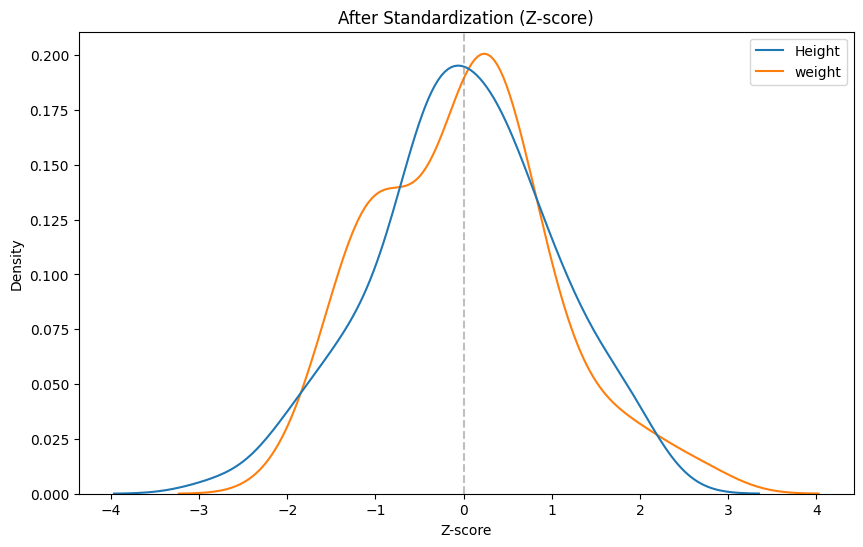

--- Standardization Summary ---
       Height  weight
count  100.00  100.00
mean     0.00   -0.00
std      1.00    1.00
min     -2.77   -2.04
25%     -0.55   -0.87
50%     -0.03    0.06
75%      0.56    0.54
max      2.15    2.83


In [5]:
# 3. 標準化（Z-score）の計算
# 公式: z = (x - mean) / std
df_std = (df - df.mean()) / df.std()

# 4. 標準化後のデータをプロット
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_std)
plt.title("After Standardization (Z-score)")
plt.xlabel("Z-score")
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

# 5. 基本統計量を確認
print("--- Standardization Summary ---")
print(df_std.describe().round(2))

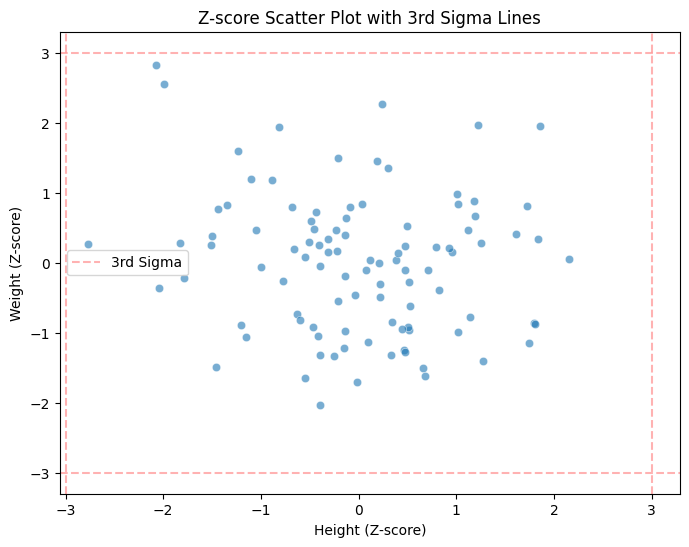

In [6]:
# 7. 散布図で外れ値を可視化
plt.figure(figsize=(8, 6))
# 標準化したデータを散布図にプロット
sns.scatterplot(x=df_std['Height'], y=df_std['weight'], alpha=0.6)

# 3σの境界線（赤点線）
plt.axhline(3, color='red', linestyle='--', alpha=0.3, label='3rd Sigma')
plt.axhline(-3, color='red', linestyle='--', alpha=0.3)
plt.axvline(3, color='red', linestyle='--', alpha=0.3)
plt.axvline(-3, color='red', linestyle='--', alpha=0.3)

plt.title("Z-score Scatter Plot with 3rd Sigma Lines")
plt.xlabel("Height (Z-score)")
plt.ylabel("Weight (Z-score)")
plt.legend()
plt.show()